<a href="https://colab.research.google.com/github/HARRY-hussein/computer_vision/blob/main/menu_detector_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Menu Detector!")

Menu Detector!


In [ ]:
# -------------------------
# Import Libraries => Google Drive bilan ishlash uchun kerakli vositani chaqiradi.
# -------------------------
from google.colab import drive
import torch
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2
import torch.nn as nn
import torch.optim as optim
# import matplotlib.pyplot as plt


from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np

In [ ]:
drive.mount('/content/drive') # Google Drive'mdagi jamiki fayllar endi Colab uchun ochiq bo'ladi.

Mounted at /content/drive


In [ ]:
# Define dataset
DATASET_PATH = '/content/drive/MyDrive/food101_dataset'
print('Dataset_path:', DATASET_PATH)


CUSTOM_CLASS_MAPPING = {
    'hamburger': 'hamburger',
    'hot_dog': 'hot_dog',
    'chocolate_cake': 'dessert', # label grouping | class consolidation
    'cheesecake': 'dessert', # label grouping | class consolidation
    'kebab': 'kebab',
    'pilaf': 'pilaf'
}


CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

print(NUM_CLASSES)
print(CLASS_TO_IDX)


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])




Dataset_path: /content/drive/MyDrive/food101_dataset
5
{'hamburger': 0, 'hot_dog': 1, 'dessert': 2, 'kebab': 3, 'pilaf': 4}


In [ ]:
# ---------------------------
# Custom Dataset Class
# ---------------------------

class FoodDataset(Dataset): # Dataset klassidan meros olgan holda yangi 'FoodDataset' klassini yaratish
    def __init__(self, images, labels, transform=None): # Klass ishga tushganda bajariladigan konstruktor
        self.images = images # Rasmlar manzillari ro'yxatini klass xususiyati sifatida saqlash
        self.labels = labels # Rasmlarga tegishli yorliqlar ro'yxatini saqlash
        self.transform = transform # Rasmlarni qayta ishlash uchun transformatsiyalarni (resize, normalize) qabul qilish

    def __len__(self): # Ma'lumotlar to'plamidagi elementlar sonini qaytarish uchun maxsus funksiya
        # print('images_length', len(self.images))
        return len(self.images) # Umumiy rasmlar sonini qaytaradi, DataLoader buni bilishi kerak

    def __getitem__(self, idx): # Berilgan indeksdagi (idx) bitta namunani olish uchun funksiya
        img_path = self.images[idx] # Indeks bo'yicha rasm manzilini ajratib olish
        # print(print('image_path', img_path))
        label = self.labels[idx] # Indeks bo'yicha mos yorliqni ajratib olish
        # print('label', label)
        try: # Xatolik yuz berishi mumkin bo'lgan qismlarni nazorat qilish
            image = Image.open(img_path) # Rasm faylini ochish
            if image.mode == "P" or image.mode == "RGBA": # Agar rasm 'P' (palitra) yoki 'RGBA' (shaffof) formatda bo'lsa
                image = image.convert("RGBA").convert("RGB") # Uni RGB formatiga o'tkazish
            else: # Boshqa holatlarda
                image = image.convert("RGB") # Rasmni RGB rang fazosiga o'tkazish
        except (UnidentifiedImageError, OSError): # Agar rasm buzilgan yoki ochib bo'lmaydigan bo'lsa
            print(f"Skipping broken image: {img_path}") # Xatolik haqida xabar berish
            return self.__getitem__((idx + 1) % len(self.images)) # Keyingi rasmga o'tib ketish (rekursiya)
        if self.transform: # Agar transformatsiyalar berilgan bo'lsa
            image = self.transform(image) # Rasmni kerakli shaklga (tensors/resize) o'tkazish
        return image, label # Tayyorlangan rasm va yorliqni qaytarish

In [ ]:
# ---------------------------
# Gather and Split Data
# ---------------------------

all_images = []

for original_class, mapped_class in CUSTOM_CLASS_MAPPING.items():
    class_path = os.path.join(DATASET_PATH, original_class)
    print('class_path:', class_path)

    if not os.path.exists(class_path):
        print(f"Warning: {class_path} not found")
        continue

    for img in os.listdir(class_path):
        if img.endswith(('.jpg', '.jpeg', '.png')):
            full_path = os.path.join(class_path, img)
            all_images.append((full_path, CLASS_TO_IDX[mapped_class]))

np.random.shuffle(all_images)

split = int(0.8 * len(all_images))
train_data = all_images[:split]
val_data = all_images[split:]

train_images, train_labels = zip(*train_data)
val_images, val_labels = zip(*val_data)

# print('all_images:', all_images)

dataset = FoodDataset(train_images, train_labels)
print(len(dataset))
img, lbl = dataset[0]

class_path: /content/drive/MyDrive/food101_dataset/hamburger
class_path: /content/drive/MyDrive/food101_dataset/hot_dog
class_path: /content/drive/MyDrive/food101_dataset/chocolate_cake
class_path: /content/drive/MyDrive/food101_dataset/cheesecake
class_path: /content/drive/MyDrive/food101_dataset/kebab
class_path: /content/drive/MyDrive/food101_dataset/pilaf
2472


In [ ]:
train_dataset = FoodDataset(train_images, train_labels, transform=transform)
val_dataset = FoodDataset(val_images, val_labels, transform=transform)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
# pretrainer model
model = mobilenet_v2(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 105MB/s] 


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

Using device: cpu


In [ ]:
criterion = nn.CrossEntropyLoss() # Loss Function
optimizer = optim.Adam(model.parameters(), lr=0.001) # weight
torch.backends.cudnn.benchmark = True # Benchmark setting | trick | 10%-20%

In [ ]:
# --- Training Loop ---
NUM_EPOCHS = 10 # Butun datasetni 10 marta ko'rib chiqishi: kutilgan natijani qay darajada olishga qarab kamayadi/ko'payadi
best_accuracy = 0.0 # Har bir epochdagi eng yuqori aniqlikni solishtirish uchun boshlang'ich qiymat

for epoch in range(NUM_EPOCHS): # ITERATION: 10 marta takrorlanadigan asosiy o'qitish sikli
    model.train() # Train jarayoni boshlandi (Dropout/BatchNorm qatlamlari ishga tushadi)
    running_loss = 0.0 # Har bir epoch ichidagi yo'qotishlar (loss) yig'indisi
    for images, labels in train_loader: # Datasetdagi 1000ta rasmni birdaniga emas, "batch_size=32" 32talab bolib-bolib beradi
        images, labels = images.to(device), labels.to(device) # Ma'lumo tlarni[image, label] CPU dan GPU (cuda) ga ko'chirish: GPU parallel hisob-kitoblarni CPU’dan ancha tez bajargani uchun model GPU’da bo‘lsa, input data ham GPU’da bo‘lishi kerak.
        optimizer.zero_grad() # Har bir batchdan oldin oldingi gradient[model xatosini kamaytirish uchun weightlarga beriladigan “tuzatish signali] qiymatlarini tozalaydi.
        outputs = model(images) # Modelga rasmlarni kiritib, bashorat (output) olish
        loss = criterion(outputs, labels) # Bashorat va haqiqiy label o'rtasidagi farqni hisoblash
        loss.backward() # Xatolik bo'yicha gradientlarni orqaga qarab hisoblash
        optimizer.step() # Model og'irliklarini (weights) gradientlar asosida yangilash
        running_loss += loss.item() # Joriy batchning yo'qotish qiymatini yig'indiga qo'shish

    # Validation - Modelning real ma'lumotlardagi holatini tekshirish
    model.eval() # Modelni baholash rejimiga o'tkazish (o'qitish to'xtaydi)
    correct = 0 # To'g'ri bashorat qilingan rasmlarni sanash uchun o'zgaruvchi
    total = 0 # Jami tekshirilgan rasmlar sonini sanash uchun o'zgaruvchi
    with torch.no_grad(): # Gradient hisoblashni o'chirish (xotirani tejash uchun)
        for images, labels in val_loader: # Val_loaderdan ma'lumotlarni batchlab olish
            images, labels = images.to(device), labels.to(device) # GPU ga o'tkazish
            outputs = model(images) # Model orqali bashoratni olish
            _, predicted = torch.max(outputs, 1) # Eng yuqori ehtimollikdagi sinf indeksini olish
            total += labels.size(0) # Joriy batchdagi rasmlar sonini total ga qo'shish
            correct += (predicted == labels).sum().item() # To'g'ri topilganlar sonini hisoblash

    val_acc = 100 * correct / total # Umumiy aniqlikni foizda hisoblash
    print(f'Epoch {(epoch+1)}/{NUM_EPOCHS} Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_acc:.2f}%')

    if val_acc > best_accuracy: # Agar yangi aniqlik avvalgisidan yaxshiroq bo'lsa
        best_accuracy = val_acc # best_accuracy ni yangilash
        torch.save(model.state_dict(), '/content/menu_detector.pth') # Model parametrlarini faylga saqlash
        print("Saved new best model!") # Saqlanganligini foydalanuvchiga bildirish

Epoch 1/10 Loss: 0.3474, Val Accuracy: 92.39%
Saved new best model!
Epoch 2/10 Loss: 0.1518, Val Accuracy: 90.78%
Epoch 3/10 Loss: 0.1631, Val Accuracy: 93.20%
Saved new best model!
Epoch 4/10 Loss: 0.0833, Val Accuracy: 89.97%
Epoch 5/10 Loss: 0.0923, Val Accuracy: 93.85%
Saved new best model!
Epoch 6/10 Loss: 0.1078, Val Accuracy: 94.01%
Saved new best model!
Epoch 7/10 Loss: 0.1144, Val Accuracy: 92.07%
Epoch 8/10 Loss: 0.1348, Val Accuracy: 93.04%
Epoch 9/10 Loss: 0.0765, Val Accuracy: 94.01%


device: cpu
Upload one or more images of your food!


Saving pilaf.jpg to pilaf.jpg


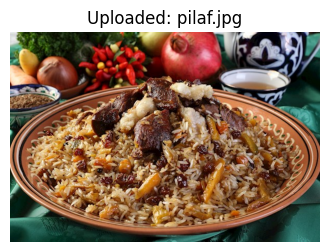

Prediction:
✅ kebab: 58.72%
✅ dessert: 35.97%
✅ hot_dog: 5.28%
✅ pilaf: 0.02%


In [ ]:
# ------------------------------------------
# Required Imports
# ------------------------------------------
import torch
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2
from PIL import Image
from google.colab import files
import io
import matplotlib.pyplot as plt

# ------------------------------------------
# Define Semantic Classes
# ------------------------------------------
CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']  # Must match training order
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}

# ------------------------------------------
# Transform for Uploaded Images (no augmentations!)
# ------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------
# Load Model
# ------------------------------------------
model = mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)
model.load_state_dict(
    torch.load('/content/menu_detector.pth', map_location='cpu')
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
model = model.to(device)
model.eval()


# ------------------------------------------
# Upload & Predict
# ------------------------------------------

print("Upload one or more images of your food!")
uploaded = files.upload()

for image_name in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[image_name])).convert('RGB')

    # Display image
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Uploaded: {image_name}')
    plt.show()

    # Predict
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)[0]
        topk = torch.topk(probs, 4)

    print("Prediction:")

    for i in range(topk.indices.size(0)):
        label = CLASSES[topk.indices[i]]
        confidence = topk.values[i].item() * 100
        print(f"✅ {label}: {confidence:.2f}%")
